In [16]:
import numpy as np
import os, sys
sys.path.append('/Users/mingxiaowei/Desktop/kennedylab/turbulence/jelly-sleap/sleap/jelly/')
from correction.analytical_correction import *

In [17]:
# thresholds = [15, 20, 30, 40, 45, 50]
thresholds = [4, 6, 8, 10, 12]
all_pp3_pts_3k = []
pp_dir = '/Users/mingxiaowei/Desktop/kennedylab/turbulence/jellyfish/video/video_1_clips/postprocess'
for thres in thresholds:
    pp_path = os.path.join(pp_dir, f'a1_raw_pts_pp3_thres{thres}.npy')
    if os.path.exists(pp_path):
    # if False:
        pp_pts = np.load(pp_path)
        all_pp3_pts_3k.append(pp_pts)
    else:
        pp_pts = preprocess3(pred_pts, thres=thres)
        all_pp3_pts_3k.append(pp_pts)
        np.save(pp_path, pp_pts)
all_pp3_pts_3k = np.array(all_pp3_pts_3k)
print(all_pp3_pts_3k.shape)

(5, 3000, 17, 2)


In [18]:
def get_velocity_and_acceleration(single_tb_across_frames):
    assert single_tb_across_frames.ndim == 2 and single_tb_across_frames.shape[1] == 2, f'invalid input shape: {single_tb_across_frames.shape}'
    velocity = np.diff(single_tb_across_frames, axis=0)
    acceleration = np.diff(velocity, axis=0)
    return velocity, acceleration

def plot_stats_for_all(all_pts):
    assert all_pts.ndim == 3 and all_pts.shape[2] == 2, f'invalid input shape: {all_pts.shape}'
    pt_cnt = all_pts.shape[1]
    
    # Create a figure with pt_cnt subplots in a column
    fig, axes = plt.subplots(pt_cnt, 1, figsize=(10, 4*pt_cnt))
    
    # Process each point
    for pt_idx in range(pt_cnt):
        # Get single point trajectory
        single_pt = all_pts[:, pt_idx, :]
        
        # Calculate velocity and acceleration
        velocity, acceleration = get_velocity_and_acceleration(single_pt)
        
        # Calculate magnitudes
        vel_mag = np.sqrt(np.sum(velocity**2, axis=1))
        acc_mag = np.sqrt(np.sum(acceleration**2, axis=1))
        
        # Plot on corresponding subplot
        ax = axes[pt_idx]
        
        # Plot velocity
        line1 = ax.plot(vel_mag, color='blue', alpha=0.7)[0]  # Get the line object
        
        # Plot acceleration on same subplot with different y-axis
        ax2 = ax.twinx()
        line2 = ax2.plot(acc_mag, color='green', alpha=0.7)[0]  # Get the line object
        
        # Customize plot
        ax.set_title(f'Point {pt_idx+1}')
        ax.set_xlabel('Frame')
        ax.set_ylabel('Velocity', color='blue')
        ax2.set_ylabel('Acceleration', color='green')
        
        # Add single legend with both lines
        ax2.legend([line1, line2], ['Velocity', 'Acceleration'], loc='upper right')
    
    plt.tight_layout()
    # return fig, axes

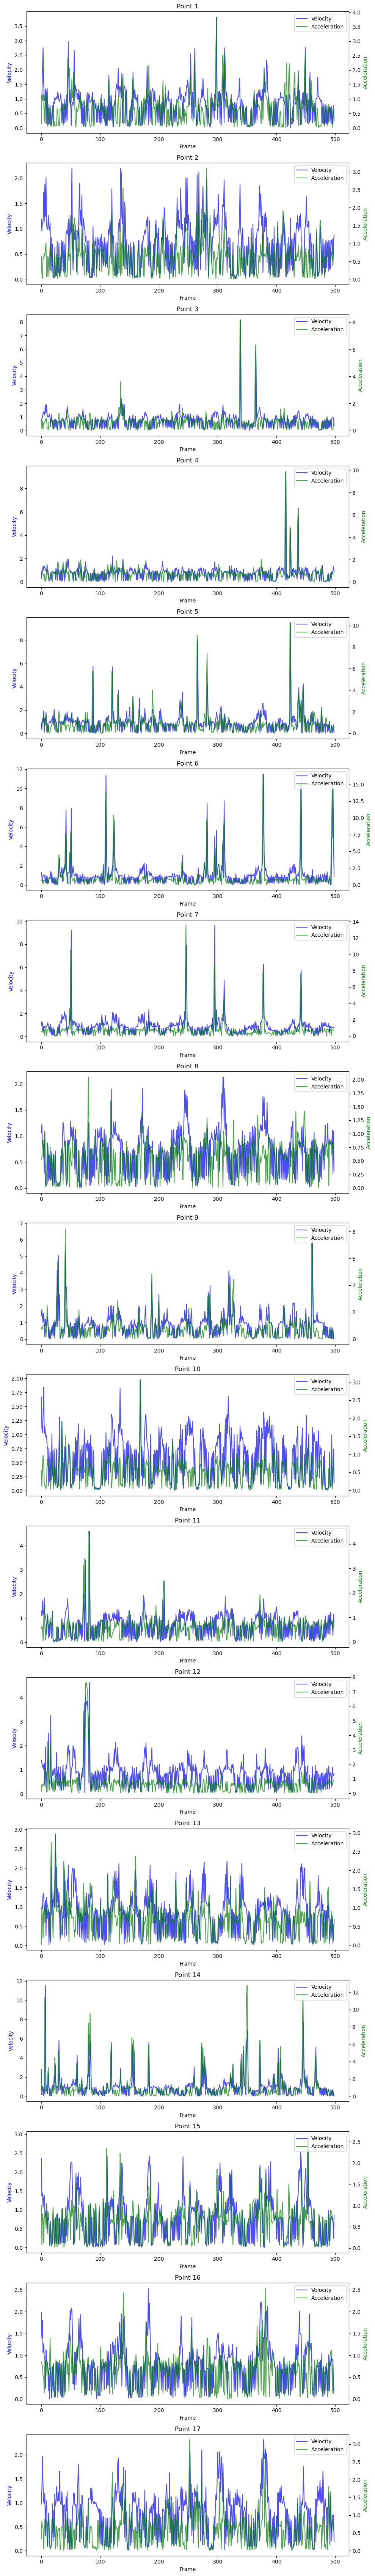

In [19]:
plot_stats_for_all(all_pp3_pts_3k[1][:500])

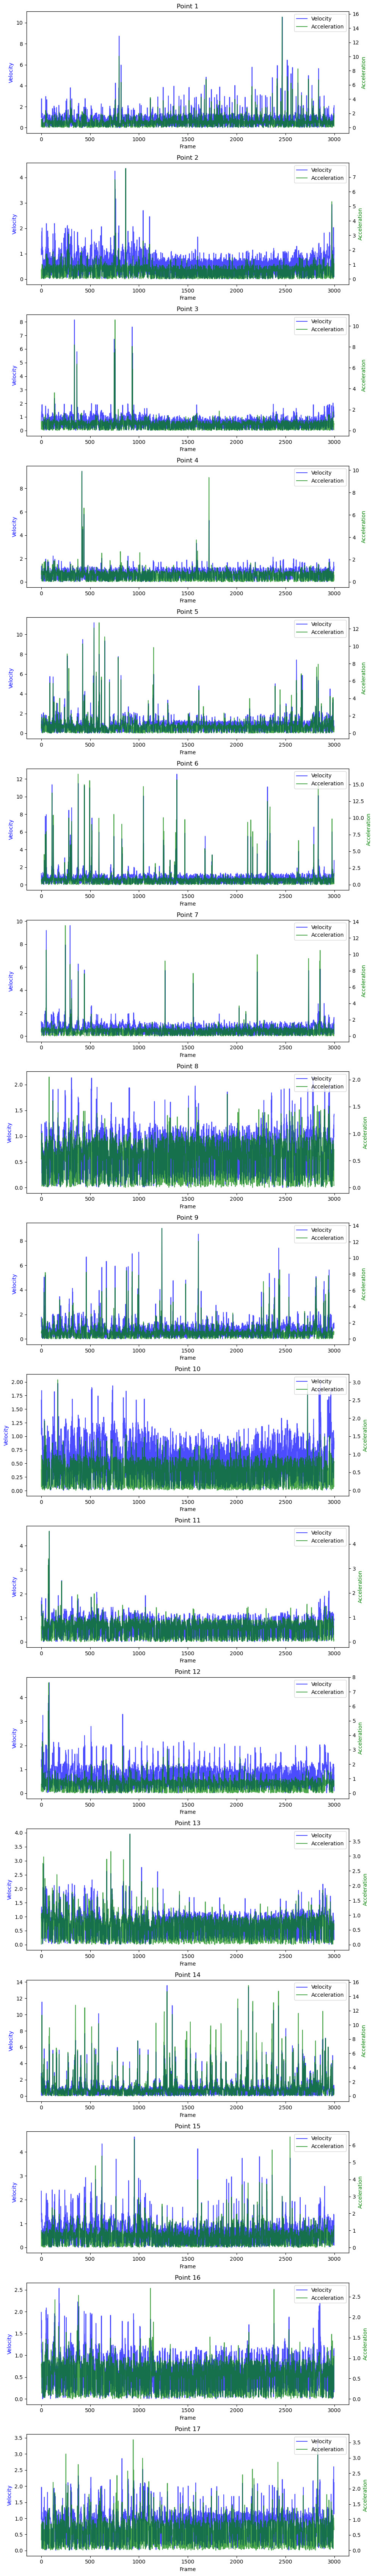

In [15]:
plot_stats_for_all(all_pp3_pts_3k[1])